# Autoencoders: code companion

This notebook accompanies `lecture_notes/19_autoencoders.pdf` and turns the main concepts into small, executable experiments.

The central idea is always the same: train a network to reconstruct its own input. Since the training target is `x` itself, we do not need labels to fit the model. Dataset labels appear here only for visualization and interpretation of the latent space.

## 1. Setup

This version uses the local MNIST files stored in `data/MNIST/raw`. Each image has `28 x 28 = 784` pixels normalized to the interval `[0, 1]`, so here `x in R^d` with `d = 784`.

We keep the official MNIST train/test split and train the autoencoders with PyTorch.


In [15]:
import os
import struct
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_LIMIT = 12000
TEST_LIMIT = 2000
BATCH_SIZE = 256
EPOCHS = 12
HIDDEN_DIM = 256
plt.rcParams["figure.figsize"] = (8, 4)


In [16]:
def find_mnist_raw_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "MNIST" / "raw"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find data/MNIST/raw from the current working directory.")


def read_idx_images(path):
    with path.open("rb") as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected magic number for images: {magic}")
        data = bytearray(f.read())

    images = torch.frombuffer(data, dtype=torch.uint8).clone()
    images = images.reshape(n_images, rows * cols).float() / 255.0
    return images, (rows, cols)


def read_idx_labels(path):
    with path.open("rb") as f:
        magic, n_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected magic number for labels: {magic}")
        data = bytearray(f.read())

    labels = torch.frombuffer(data, dtype=torch.uint8).clone().long()
    if labels.numel() != n_labels:
        raise ValueError("Label file has an unexpected length.")
    return labels


def subset_tensor(X, y, limit, seed):
    if limit is None or limit >= X.shape[0]:
        return X, y
    generator = torch.Generator().manual_seed(seed)
    idx = torch.randperm(X.shape[0], generator=generator)[:limit]
    return X[idx], y[idx]


def to_numpy(tensor):
    return np.asarray(tensor.detach().cpu().tolist(), dtype=np.float32)


mnist_raw_dir = find_mnist_raw_dir()
X_train, image_shape = read_idx_images(mnist_raw_dir / "train-images-idx3-ubyte")
y_train = read_idx_labels(mnist_raw_dir / "train-labels-idx1-ubyte")
X_test, _ = read_idx_images(mnist_raw_dir / "t10k-images-idx3-ubyte")
y_test = read_idx_labels(mnist_raw_dir / "t10k-labels-idx1-ubyte")

X_train, y_train = subset_tensor(X_train, y_train, TRAIN_LIMIT, RANDOM_STATE)
X_test, y_test = subset_tensor(X_test, y_test, TEST_LIMIT, RANDOM_STATE + 1)

INPUT_DIM = X_train.shape[1]
X_train_np = to_numpy(X_train)
X_test_np = to_numpy(X_test)

print("MNIST directory:", mnist_raw_dir)
print("device:", DEVICE)
print("X_train:", tuple(X_train.shape))
print("X_test: ", tuple(X_test.shape))
print("image shape:", image_shape)
print("pixel min/max:", X_train.min().item(), X_train.max().item())


MNIST directory: /Users/ebezerra/ailab/cic1205/data/MNIST/raw
device: cpu
X_train: (12000, 784)
X_test:  (2000, 784)
image shape: (28, 28)
pixel min/max: 0.0 1.0


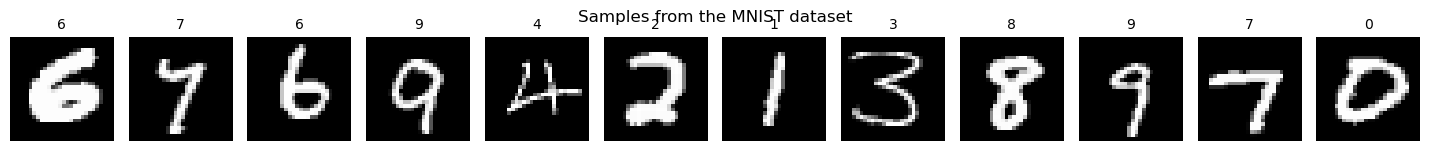

In [17]:
def plot_digit_grid(vectors, titles=None, n=10, image_shape=image_shape, cmap="gray"):
    n = min(n, len(vectors))
    fig, axes = plt.subplots(1, n, figsize=(1.2 * n, 1.4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(np.asarray(vectors[i]).reshape(image_shape), cmap=cmap, vmin=0, vmax=1)
        if titles is not None:
            ax.set_title(str(titles[i]), fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    return fig

plot_digit_grid(X_train_np[:12], titles=y_train[:12].tolist(), n=12)
plt.suptitle("Samples from the MNIST dataset", y=1.05)
plt.show()


## 2. Architecture: encoder, bottleneck, and decoder

An autoencoder combines two learned functions:

- `z = f_phi(x)`: the encoder compresses the input into a latent code.
- `x_hat = g_psi(z)`: the decoder tries to reconstruct the input from that code.

In scikit-learn we do not explicitly define `Encoder` and `Decoder` modules, but the architecture `64 -> 32 -> latent_dim -> 32 -> 64` has exactly this interpretation. The middle layer is the bottleneck.


In [18]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


def train_autoencoder(model, train_inputs, train_targets=None, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3):
    if train_targets is None:
        train_targets = train_inputs

    loader = DataLoader(
        TensorDataset(train_inputs, train_targets),
        batch_size=batch_size,
        shuffle=True,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []

    model.to(DEVICE)
    model.train()
    for _ in range(epochs):
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            recon = model(xb)
            loss = loss_fn(recon, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        history.append(total_loss / len(loader.dataset))
    return history


@torch.no_grad()
def reconstruct(model, X, batch_size=512):
    model.eval()
    outputs = []
    loader = DataLoader(X, batch_size=batch_size, shuffle=False)
    for xb in loader:
        xb = xb.to(DEVICE)
        outputs.append(model(xb).cpu())
    return torch.cat(outputs, dim=0)


ae = AutoEncoder(latent_dim=8, hidden_dim=HIDDEN_DIM)

# Unsupervised training: the input is also the target.
history = train_autoencoder(ae, X_train)

X_hat = reconstruct(ae, X_test)
X_hat_np = to_numpy(X_hat)
print("epochs run:", len(history))
print("test reconstruction MSE:", ((X_test - X_hat) ** 2).mean().item())


epochs run: 12
test reconstruction MSE: 0.03673076629638672


## 3. Reconstruction loss

In the notes, the objective function is a loss between `x` and `x_hat`. Here we use MSE:

$$L(x, \hat{x}) = \frac{1}{d}\lVert x - \hat{x}\rVert_2^2.$$

Notice that digit labels do not enter the optimization. The model only learns to preserve enough information to reconstruct the image.


In [19]:
def reconstruction_mse(X_true, X_recon):
    return ((X_true - X_recon) ** 2).mean(dim=1)

errors = reconstruction_mse(X_test, X_hat)
print("mean error per image:", errors.mean().item())
print("lowest error:", errors.min().item())
print("highest error:", errors.max().item())


mean error per image: 0.03673076629638672
lowest error: 0.0028366693295538425
highest error: 0.10869214683771133


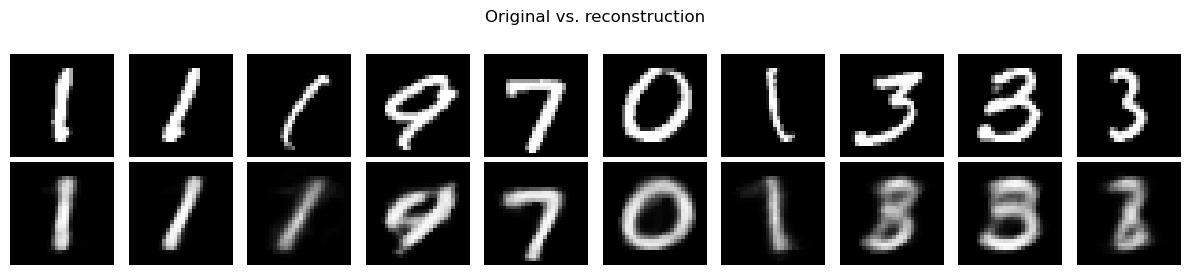

In [20]:
n = 10
fig, axes = plt.subplots(2, n, figsize=(1.2 * n, 2.8))
for i in range(n):
    axes[0, i].imshow(X_test_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(X_hat_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", fontsize=10)
axes[1, 0].set_ylabel("recon", fontsize=10)
plt.suptitle("Original vs. reconstruction")
plt.tight_layout()
plt.show()


## 4. The effect of the bottleneck

The latent dimension `k` controls compression. Small values force compact codes, but may lose details; large values reduce reconstruction error, but may approach an almost identical copy of the input.


latent_dim= 2 | test MSE=0.06062 | epochs=12
latent_dim= 4 | test MSE=0.06094 | epochs=12
latent_dim= 8 | test MSE=0.03122 | epochs=12
latent_dim=16 | test MSE=0.03031 | epochs=12
latent_dim=32 | test MSE=0.01878 | epochs=12


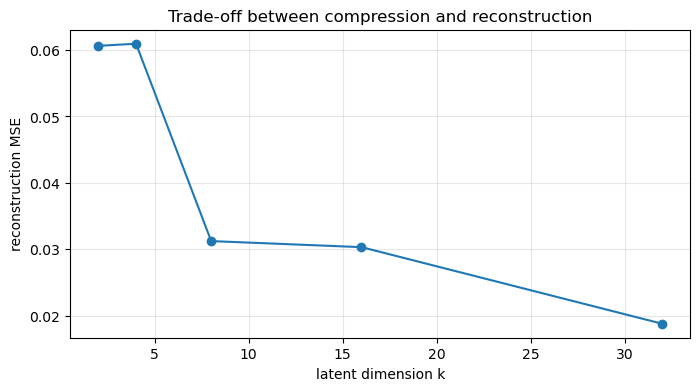

In [21]:
latent_dims = [2, 4, 8, 16, 32]
results = []
models = {}

for k in latent_dims:
    model = AutoEncoder(latent_dim=k, hidden_dim=HIDDEN_DIM)
    history = train_autoencoder(model, X_train)
    recon = reconstruct(model, X_test)
    mse = ((X_test - recon) ** 2).mean().item()
    results.append((k, mse, len(history)))
    models[k] = model

for k, mse, n_iter in results:
    print(f"latent_dim={k:2d} | test MSE={mse:.5f} | epochs={n_iter}")

plt.plot([r[0] for r in results], [r[1] for r in results], marker="o")
plt.xlabel("latent dimension k")
plt.ylabel("reconstruction MSE")
plt.title("Trade-off between compression and reconstruction")
plt.grid(True, alpha=0.3)
plt.show()


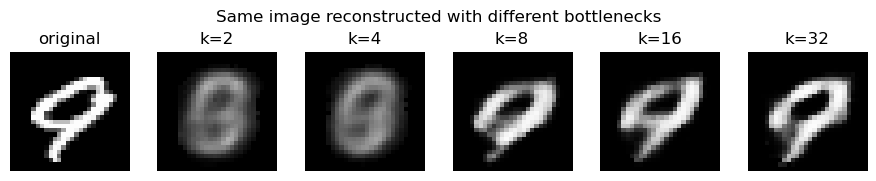

In [22]:
example_idx = 3
fig, axes = plt.subplots(1, len(latent_dims) + 1, figsize=(1.5 * (len(latent_dims) + 1), 1.8))
axes[0].imshow(X_test_np[example_idx].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("original")
axes[0].axis("off")

for ax, k in zip(axes[1:], latent_dims):
    recon = reconstruct(models[k], X_test[example_idx:example_idx + 1])
    ax.imshow(to_numpy(recon)[0].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"k={k}")
    ax.axis("off")

plt.suptitle("Same image reconstructed with different bottlenecks")
plt.tight_layout()
plt.show()


## 5. Latent space

Now the encoder is an explicit PyTorch module, so extracting the bottleneck representation is simply a forward pass through `model.encode`.


In [23]:
@torch.no_grad()
def encode_dataset(model, X, batch_size=512):
    model.eval()
    outputs = []
    loader = DataLoader(X, batch_size=batch_size, shuffle=False)
    for xb in loader:
        xb = xb.to(DEVICE)
        outputs.append(model.encode(xb).cpu())
    return torch.cat(outputs, dim=0)

best_ae = models[8]
Z_test = to_numpy(encode_dataset(best_ae, X_test))
print("latent space shape:", Z_test.shape)


latent space shape: (2000, 8)


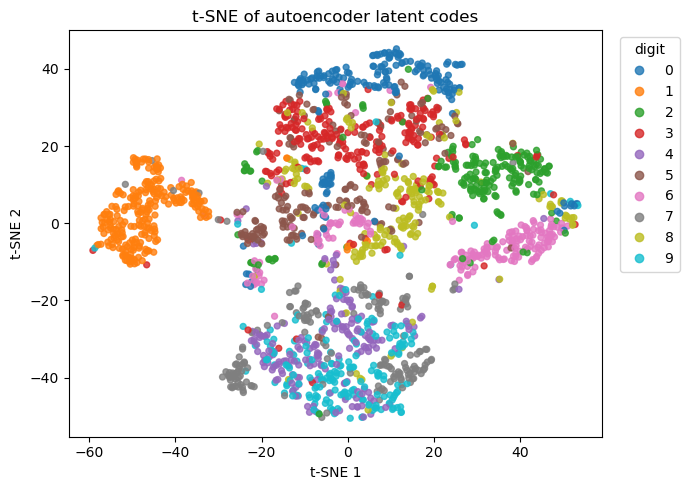

In [24]:
# Since k=8, we project the codes to 2D with t-SNE only for visualization.
tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=RANDOM_STATE)
Z_2d = tsne.fit_transform(Z_test)

y_test_np = np.asarray(y_test.tolist(), dtype=np.int64)
plt.figure(figsize=(7, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=y_test_np, cmap="tab10", s=18, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("t-SNE of autoencoder latent codes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


Labels were used only to color the plot. If points from the same digit appear close together, this suggests that the autoencoder learned representations related to the visual structure of digits, even without supervision.

Important: t-SNE is a visualization tool. Do not treat global distances in the plot as precise metrics of the original latent space.


## 6. Denoising autoencoder

In a denoising autoencoder, we corrupt the input before the encoder, but compare the output with the clean image:

$$\tilde{x} = x + \epsilon, \quad \hat{x} = g_\psi(f_\phi(\tilde{x})), \quad L = L(x, \hat{x}).$$

This detail is crucial: the loss target is `x`, not `x_tilde`.


In [25]:
def add_gaussian_noise(X, noise_factor=0.35, seed=RANDOM_STATE):
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(X.shape, generator=generator, dtype=X.dtype)
    noisy = X + noise_factor * noise
    return torch.clamp(noisy, 0.0, 1.0)

noise_factor = 0.35
X_train_noisy = add_gaussian_noise(X_train, noise_factor=noise_factor, seed=RANDOM_STATE)
X_test_noisy = add_gaussian_noise(X_test, noise_factor=noise_factor, seed=RANDOM_STATE + 1)

dae = AutoEncoder(latent_dim=8, hidden_dim=HIDDEN_DIM)

# Corrupted input, clean target.
dae_history = train_autoencoder(dae, X_train_noisy, train_targets=X_train)
X_denoised = reconstruct(dae, X_test_noisy)
X_test_noisy_np = to_numpy(X_test_noisy)
X_denoised_np = to_numpy(X_denoised)

print("epochs run:", len(dae_history))
print("MSE of noisy image vs. clean image: ", ((X_test - X_test_noisy) ** 2).mean().item())
print("MSE of reconstruction vs. clean image:", ((X_test - X_denoised) ** 2).mean().item())


epochs run: 12
MSE of noisy image vs. clean image:  0.06257397681474686
MSE of reconstruction vs. clean image: 0.03752976655960083


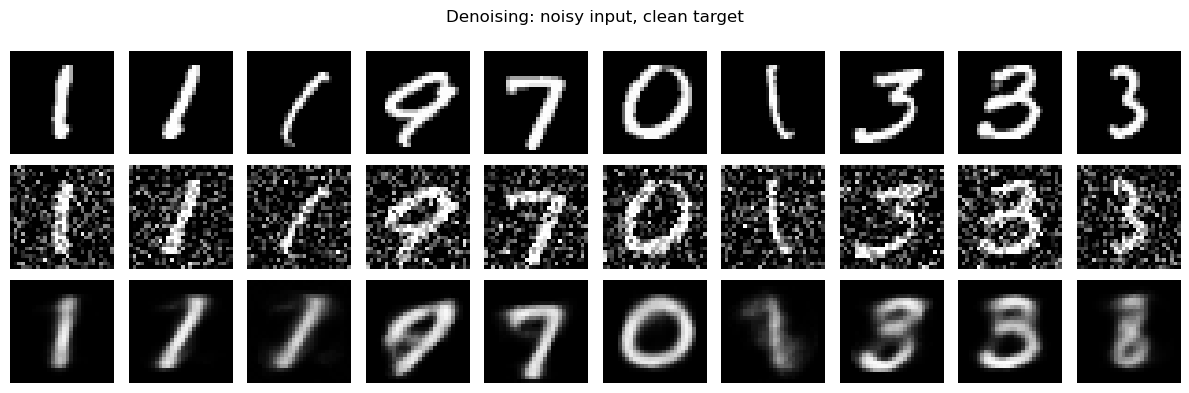

In [26]:
n = 10
fig, axes = plt.subplots(3, n, figsize=(1.2 * n, 4.0))
for i in range(n):
    axes[0, i].imshow(X_test_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(X_test_noisy_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    axes[2, i].imshow(X_denoised_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[2, i].axis("off")
axes[0, 0].set_ylabel("clean", fontsize=10)
axes[1, 0].set_ylabel("noisy", fontsize=10)
axes[2, 0].set_ylabel("recon", fontsize=10)
plt.suptitle("Denoising: noisy input, clean target")
plt.tight_layout()
plt.show()


## 7. Reconstruction error as an anomaly signal

If we train an autoencoder only on data considered normal, it tends to reconstruct samples similar to that set more accurately. Inputs outside the training distribution often have higher reconstruction error.

Here, as a didactic demonstration, we train only on digits `0` through `4` and treat `5` through `9` as out of distribution.


In [27]:
normal_train_mask = y_train <= 4
normal_test_mask = y_test <= 4
anom_test_mask = y_test >= 5

Xn_train = X_train[normal_train_mask]
Xn_test = X_test[normal_test_mask]
X_anom = X_test[anom_test_mask]

anom_ae = AutoEncoder(latent_dim=8, hidden_dim=HIDDEN_DIM)
anom_history = train_autoencoder(anom_ae, Xn_train)

normal_recon = reconstruct(anom_ae, Xn_test)
anom_recon = reconstruct(anom_ae, X_anom)

normal_err = reconstruction_mse(Xn_test, normal_recon)
anom_err = reconstruction_mse(X_anom, anom_recon)

print("epochs run:", len(anom_history))
print("mean error on seen digits (0-4):", normal_err.mean().item())
print("mean error on unseen digits (5-9):", anom_err.mean().item())


epochs run: 12
mean error on seen digits (0-4): 0.03690721094608307
mean error on unseen digits (5-9): 0.05827993154525757


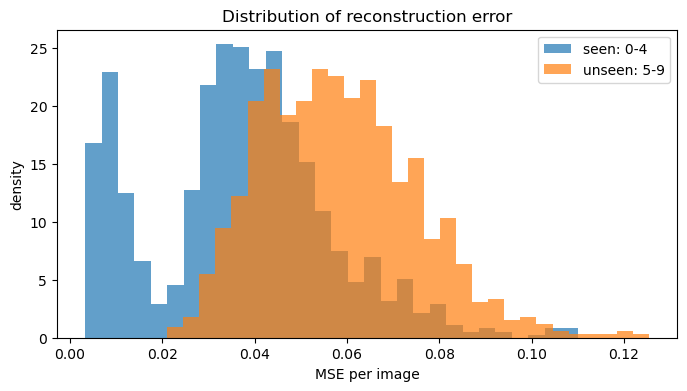

In [28]:
plt.hist(to_numpy(normal_err), bins=30, alpha=0.7, label="seen: 0-4", density=True)
plt.hist(to_numpy(anom_err), bins=30, alpha=0.7, label="unseen: 5-9", density=True)
plt.xlabel("MSE per image")
plt.ylabel("density")
plt.title("Distribution of reconstruction error")
plt.legend()
plt.show()


## 8. Variational autoencoders (Section 9 in the notes)

In the notes, the key change from a standard autoencoder to a VAE is that the encoder no longer outputs a single latent code. Instead, it outputs the parameters `mu` and `logvar` of a Gaussian distribution, we sample `z` with the reparameterization trick, and we add a KL penalty that keeps the latent space close to `N(0, I)`.

This gives the model a smoother latent space and makes random sampling meaningful: we can draw `z ~ N(0, I)` and decode it into a new digit.


In [29]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode_stats(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode_stats(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(x, recon, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss


def train_vae(model, train_inputs, epochs=10, batch_size=BATCH_SIZE, lr=1e-3):
    loader = DataLoader(train_inputs, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    model.to(DEVICE)
    model.train()
    for _ in range(epochs):
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        for xb in loader:
            xb = xb.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(xb)
            loss, recon_loss, kl_loss = vae_loss(xb, recon, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_recon += recon_loss.item() * xb.size(0)
            total_kl += kl_loss.item() * xb.size(0)
        history.append({
            "loss": total_loss / len(loader.dataset),
            "recon": total_recon / len(loader.dataset),
            "kl": total_kl / len(loader.dataset),
        })
    return history


@torch.no_grad()
def reconstruct_with_vae(model, X, batch_size=512):
    model.eval()
    outputs = []
    for xb in DataLoader(X, batch_size=batch_size, shuffle=False):
        recon, _, _ = model(xb.to(DEVICE))
        outputs.append(recon.cpu())
    return torch.cat(outputs, dim=0)


@torch.no_grad()
def encode_vae_means(model, X, batch_size=512):
    model.eval()
    outputs = []
    for xb in DataLoader(X, batch_size=batch_size, shuffle=False):
        mu, _ = model.encode_stats(xb.to(DEVICE))
        outputs.append(mu.cpu())
    return torch.cat(outputs, dim=0)


@torch.no_grad()
def sample_vae(model, n_samples=10):
    model.eval()
    latent_dim = model.mu_layer.out_features
    z = torch.randn(n_samples, latent_dim, device=DEVICE)
    return model.decode(z).cpu()


vae = VariationalAutoEncoder(latent_dim=2, hidden_dim=HIDDEN_DIM)
vae_history = train_vae(vae, X_train, epochs=10)
vae_recon = reconstruct_with_vae(vae, X_test)
vae_recon_np = to_numpy(vae_recon)
vae_latent_means = to_numpy(encode_vae_means(vae, X_test))
vae_samples_np = to_numpy(sample_vae(vae, n_samples=12))

print("final VAE loss:", vae_history[-1]["loss"])
print("final reconstruction term:", vae_history[-1]["recon"])
print("final KL term:", vae_history[-1]["kl"])
print("test reconstruction MSE:", ((X_test - vae_recon) ** 2).mean().item())


final VAE loss: 175.44347587076822
final reconstruction term: 170.1414609375
final KL term: 5.302014893849691
test reconstruction MSE: 0.05091002210974693


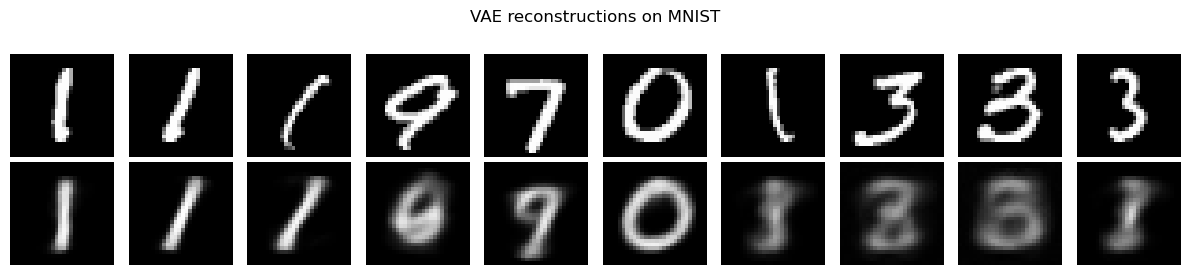

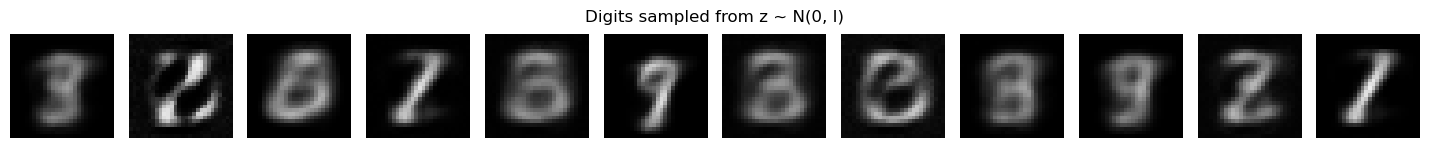

In [30]:
n = 10
fig, axes = plt.subplots(2, n, figsize=(1.2 * n, 2.8))
for i in range(n):
    axes[0, i].imshow(X_test_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(vae_recon_np[i].reshape(image_shape), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", fontsize=10)
axes[1, 0].set_ylabel("VAE", fontsize=10)
plt.suptitle("VAE reconstructions on MNIST")
plt.tight_layout()
plt.show()

plot_digit_grid(vae_samples_np, n=12, image_shape=image_shape)
plt.suptitle("Digits sampled from z ~ N(0, I)", y=1.05)
plt.show()


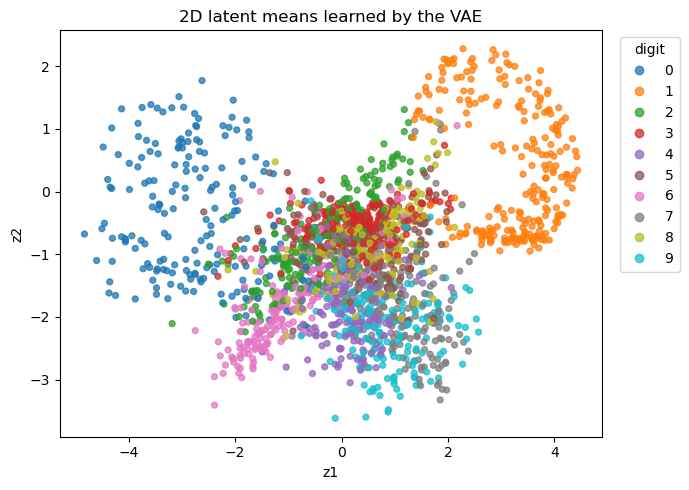

In [31]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(vae_latent_means[:, 0], vae_latent_means[:, 1], c=y_test_np, cmap="tab10", s=18, alpha=0.75)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("2D latent means learned by the VAE")
plt.xlabel("z1")
plt.ylabel("z2")
plt.tight_layout()
plt.show()


## 9. Common pitfalls to check in code

- Loss and output activation must be compatible. For MSE, a linear output is acceptable; for BCE, we usually use a sigmoid output.
- Very low reconstruction error does not guarantee a good representation; the bottleneck may be too large.
- In denoising, the loss must compare the reconstruction with the clean input.
- In a VAE, the KL term must use the latent distribution parameters, not the sampled reconstruction.
- Blurry or imperfect reconstructions are expected when the bottleneck is small or the model is simple.


## 10. Connection with the lecture notes

This notebook covers the main variants discussed in the notes using local MNIST data and PyTorch: vanilla autoencoders, denoising autoencoders, anomaly detection through reconstruction error, and VAEs.

Across all of them, the backbone is the same: an encoder, a bottleneck representation, a decoder, and a reconstruction objective. The VAE extends that structure with a probabilistic latent space and a KL regularization term.


## Quick exercises

1. Change `latent_dim=8` to `latent_dim=2` in the vanilla autoencoder and observe the impact on reconstructions and on t-SNE.
2. Increase `noise_factor` in the denoising autoencoder. At what point does the task become too difficult?
3. Use the latent codes `Z_test` as input to a simple classifier. Is the accuracy close to the one obtained with the original pixels?
4. In the anomaly section, change which digits are considered normal and observe how the error distributions change.
5. In the VAE, increase the latent dimension from `2` to `8`. What improves in reconstruction, and what do you lose in terms of direct latent-space visualization?
6. Modify the VAE loss by multiplying the KL term by a constant `beta`. How does this change the balance between reconstruction quality and latent-space organization?
